[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuantLet/EMQA/blob/main/EMQA_news_impact/EMQA_news_impact.ipynb)

# EMQA_news_impact
News impact curve: GARCH vs GJR-GARCH -- showing asymmetric volatility response.
**Output:** `news_impact_curve.pdf`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'savefig.transparent': True,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'figure.figsize': (12, 6),
})

COLORS = {
    'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32',
    'orange': '#E67E22', 'purple': '#8E44AD', 'gray': '#808080',
    'cyan': '#00BCD4', 'amber': '#B5853F'
}

def save_fig(fig, name):
    fig.savefig(name, bbox_inches='tight', transparent=True, dpi=300,
                facecolor='none', edgecolor='none')
    print(f"Saved: {name}")
    if name.endswith('.pdf'):
        png_name = name[:-4] + '.png'
        fig.savefig(png_name, bbox_inches='tight', transparent=True, dpi=300,
                    facecolor='none', edgecolor='none')
        print(f"Saved: {png_name}")


Saved: news_impact_curve.pdf


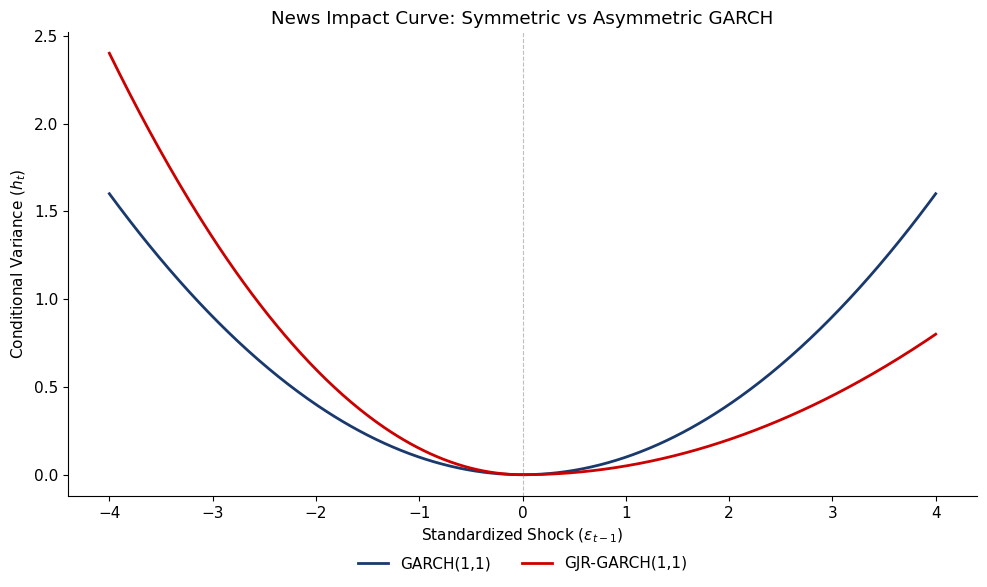

In [2]:
# News impact curves (analytical)
# GARCH(1,1): h_t = omega + alpha * eps^2 + beta * h_{t-1}
# GJR-GARCH:  h_t = omega + (alpha + gamma * I(eps<0)) * eps^2 + beta * h_{t-1}

omega = 0.00001
alpha_garch = 0.10
beta_ = 0.85
alpha_gjr = 0.05
gamma_gjr = 0.10

# Assume h_{t-1} = unconditional variance
h_unc_garch = omega / (1 - alpha_garch - beta_)
h_unc_gjr = omega / (1 - alpha_gjr - 0.5 * gamma_gjr - beta_)

eps = np.linspace(-4, 4, 500)

# GARCH news impact
nic_garch = omega + alpha_garch * eps**2 + beta_ * h_unc_garch

# GJR-GARCH news impact
indicator = (eps < 0).astype(float)
nic_gjr = omega + (alpha_gjr + gamma_gjr * indicator) * eps**2 + beta_ * h_unc_gjr

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(eps, nic_garch, color=COLORS['blue'], linewidth=2, label='GARCH(1,1)')
ax.plot(eps, nic_gjr, color=COLORS['red'], linewidth=2, label='GJR-GARCH(1,1)')
ax.axvline(0, color=COLORS['gray'], linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Standardized Shock ($\\epsilon_{t-1}$)')
ax.set_ylabel('Conditional Variance ($h_t$)')
ax.set_title('News Impact Curve: Symmetric vs Asymmetric GARCH')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=2)

plt.tight_layout()
save_fig(fig, 'news_impact_curve.pdf')
plt.show()